In [5]:
import subprocess
import json

from typing import Annotated, List, TypedDict, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [6]:
def get_github_token() -> str | None:
    """Возвращает персональный токен GitHub, используя GitHub CLI.

    Вместо того чтобы хранить токен в коде или переменных окружения,
    мы делегируем его получение инструменту ``gh`` (GitHub CLI).
    Это безопасно: токен никогда не попадает в файлы проекта.

    Returns:
        Строка с токеном если GitHub CLI установлен и пользователь
        аутентифицирован (``gh auth login``), иначе ``None``.

    Raises:
        Не бросает исключений — все ошибки перехватываются внутри.
    """
    try:
        token = subprocess.check_output(["gh", "auth", "token"]).decode("utf-8").strip()
        return token
    except Exception as e:
        print("Ошибка: Убедитесь, что GitHub CLI установлен и вы залогинены (gh auth login)")
        return None


In [19]:
# MODEL = "Llama-3.3-70B-Instruct" - not support more than one tool call at this time
MODEL = "gpt-4o-mini"

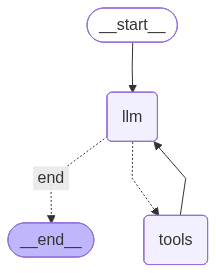

In [20]:
# ----------------------------
# 0) Tiny in-memory "database"
# ----------------------------
DATABASE = {
    "flights": {
        # flight_key -> flight record
        "AY001_2026-02-22": {
            "flight_key": "AY001_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "09:30",
            "seats": 3,
            "price": 120,
        },
        "AY101_2026-02-22": {
            "flight_key": "AY101_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "16:10",
            "seats": 1,
            "price": 155,
        },
    },
    "bookings": {
        # booking_id -> booking record
        "BKG-123": {
            "booking_id": "BKG-123",
            "flight_key": "AY001_2026-02-22",
            "passenger_name": "Jane Doe",
            "status": "confirmed",
        }
    },
}


# -----------------------
# 1) Tools
# -----------------------
@tool
def get_booking(booking_id: str) -> str:
    """Возвращает данные бронирования и связанного рейса.

    Args:
        booking_id: Идентификатор бронирования (например, ``BKG-123``).

    Returns:
        JSON-строка с полями бронирования и вложенным объектом рейса.
        Если бронирование не найдено, возвращает JSON с ``error``.

    Example:
        >>> get_booking.invoke({"booking_id": "BKG-123"})
        '{"booking_id": "BKG-123", ...}'
    """
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": f"Booking {booking_id} not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"], {})
    return json.dumps(
        {"booking_id": booking_id, **booking_record, "flight": flight_record},
        ensure_ascii=False,
    )


@tool
def search_flights(origin: str, destination: str, date: str) -> str:
    """Ищет доступные рейсы по направлению и дате.

    Args:
        origin: Код аэропорта вылета (IATA), например ``HEL``.
        destination: Код аэропорта прилета (IATA), например ``AMS``.
        date: Дата вылета в формате ``YYYY-MM-DD``.

    Returns:
        JSON-строка со списком доступных рейсов (``seats > 0``),
        отсортированным по времени вылета.

    Example:
        >>> search_flights.invoke({"origin": "HEL", "destination": "AMS", "date": "2026-02-22"})
        '[{"flight_key": "AY001_2026-02-22", ...}]'
    """
    matching_flights = [
        flight
        for flight in DATABASE["flights"].values()
        if flight["from"] == origin
        and flight["to"] == destination
        and flight["date"] == date
        and flight["seats"] > 0
    ]
    return json.dumps(
        sorted(matching_flights, key=lambda f: f["time"]),
        ensure_ascii=False,
    )


@tool
def cancel_booking(booking_id: str) -> str:
    """Отменяет бронирование и освобождает место на рейсе.

    Args:
        booking_id: Идентификатор бронирования.

    Returns:
        JSON-строка:
        - при успехе: ``{"success": true, "refund": <amount>}``
        - при ошибке: ``{"error": "Booking not found"}``

    Note:
        Это учебный in-memory сценарий: операция меняет глобальный словарь
        ``DATABASE`` прямо во время выполнения ноутбука.
    """
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": "Booking not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"])
    booking_record["status"] = "cancelled"

    if flight_record:
        flight_record["seats"] += 1

    refund_amount = flight_record["price"] if flight_record else 0
    return json.dumps({"success": True, "refund": refund_amount}, ensure_ascii=False)


TOOLS = [get_booking, search_flights, cancel_booking]


# -----------------------
# 2) Prompt (system)
# -----------------------
POLICIES: List[str] = [
    "Используйте инструменты, когда они необходимы для точного ответа",
    "Никогда не выдумывайте детали бронирования, информацию о рейсах, ценах или статусах",
    "Если информации недостаточно, задавайте уточняющие вопросы",
    "Запрашивайте подтверждение перед любой отменой бронирования. Явно запросите и дождитесь подтверждения пользователя",
    "Проверьте текущее бронирование, прежде чем предлагать изменения.",
]

SYSTEM_PROMPT = ("Вы являетесь виртуальным ассистентом авиакомпании." + f"\nPOLICIES: {chr(10).join(f"* {p}" for p in POLICIES)}").strip()


# -----------------------
# 3) Agent state with a reducer: messages will be appended, not overwritten
# -----------------------
class AgentStateRed(TypedDict):
    """Состояние графа агента.

    Attributes:
        messages: История сообщений (human/ai/tool/system).
            Аннотация ``add_messages`` включает reducer LangGraph:
            новые сообщения добавляются к истории, а не перезаписывают ее.
    """

    messages: Annotated[List[BaseMessage], add_messages]


# -----------------------
# 4) LLM node
# -----------------------
# llm = ChatOpenAI(model=MODEL)
# bind_tools(TOOLS) разрешает модели возвращать structured tool_calls,
# которые затем исполняются узлом ToolNode.
llm_with_tools = ChatOpenAI(
    base_url="https://models.inference.ai.azure.com",
    api_key=get_github_token(),
    model=MODEL,
    temperature=0,
    ).bind_tools(TOOLS)


def llm_with_tools_node(state: AgentStateRed) -> AgentStateRed:
    """Узел LLM: формирует ответ модели на основе текущей истории.

    Args:
        state: Текущее состояние графа с накопленными сообщениями.

    Returns:
        Частичное обновление состояния с одним новым сообщением AI.
        LangGraph добавит его в ``messages`` благодаря reducer'у.

    Note:
        Системный промпт добавляется на каждом шаге перед вызовом модели,
        чтобы сохранять правила поведения неизменными.
    """
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm_with_tools.invoke(msgs)
    return {"messages": [resp]}


# ----------------------------
# 5) Router: decide whether to call tools
# ----------------------------
def route_after_llm(state: AgentStateRed) -> Literal["tools", "end"]:
    """Маршрутизирует выполнение после LLM-узла.

    Args:
        state: Состояние после выполнения узла ``llm``.

    Returns:
        "tools": если модель запросила хотя бы один tool call.
        "end": если модель сразу дала финальный ответ без tools.
    """
    last = state["messages"][-1]
    # If the model requested tool calls, send to ToolNode; else finish.
    has_tool_calls = getattr(last, "tool_calls", None)
    return "tools" if has_tool_calls else "end"


# ----------------------------
# 6) Build the graph
# ----------------------------
# Граф имеет петлю llm -> tools -> llm:
# 1) LLM решает, нужен ли tool
# 2) Если нужен, ToolNode исполняет вызов и пишет ToolMessage в историю
# 3) Управление возвращается в LLM, чтобы интерпретировать результат tool
# 4) Когда tool_calls больше нет, граф завершает работу
graph_with_tools = StateGraph(AgentStateRed)

graph_with_tools.add_node("llm", llm_with_tools_node)
graph_with_tools.add_node("tools", ToolNode(TOOLS))

graph_with_tools.set_entry_point("llm")

# If LLM asked for tools -> tools; otherwise -> END
graph_with_tools.add_conditional_edges(
    "llm",
    route_after_llm,
    {"tools": "tools", "end": END},
)

# After tools run, go back to LLM (so it can interpret tool results and answer / ask next question)
graph_with_tools.add_edge("tools", "llm")

app_with_tools = graph_with_tools.compile()

app_with_tools

In [24]:
def ask(user_text: str, app) -> str:
    """Запускает агент на одном пользовательском запросе.

    Args:
        user_text: Текст запроса пользователя.
        app: Скомпилированный LangGraph app (например, ``app_with_tools``).

    Returns:
        Текст финального ответа агента.

    Example:
        >>> ask("Найдите авиабилеты из HEL в AMS на 2026-02-22", app_with_tools)
        'Нашел 2 рейса ...'
    """
    print("\n🟣 USER QUERY")
    print(">" * 50)
    print(user_text)

    state = {"messages": [HumanMessage(content=user_text)]}
    out = app.invoke(state)
    answer = out["messages"][-1].content

    print("\n🟢 AGENT RESPONSE")
    print("<" * 50)
    print(answer)
    print()
    return answer


def run_with_stream_trace(user_text: str, app) -> str:
    """Запускает граф в stream-режиме и печатает последовательность шагов.

    Args:
        user_text: Текст пользовательского запроса.
        app: Скомпилированный LangGraph app.

    Returns:
        Финальный текст ответа агента.
    """
    print("\n🧭 STREAM TRACE")
    print(f"USER: {user_text}")

    final_answer = ""
    step_idx = 0

    for update in app.stream(
        {"messages": [HumanMessage(content=user_text)]},
        stream_mode="updates",
    ):
        step_idx += 1
        node_name = next(iter(update.keys()))
        payload = update[node_name]
        messages = payload.get("messages", [])

        print(f"\nSTEP {step_idx} | NODE: {node_name}")

        for msg in messages:
            msg_type = getattr(msg, "type", msg.__class__.__name__)
            print(f"- message type: {msg_type}")

            if hasattr(msg, "tool_calls") and msg.tool_calls:
                print(f"  tool_calls: {msg.tool_calls}")

            if hasattr(msg, "content") and msg.content:
                text = str(msg.content)
                preview = text if len(text) <= 200 else text[:200] + "..."
                print(f"  content: {preview}")

            if msg_type == "ai" and hasattr(msg, "content"):
                final_answer = msg.content

    print("\n✅ FINAL ANSWER")
    print(final_answer)
    return final_answer

In [21]:
ask("Найдите авиабилеты из HEL в AMS на 2026-02-22", app_with_tools)


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Найдите авиабилеты из HEL в AMS на 2026-02-22

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Вот доступные авиабилеты из Хельсинки (HEL) в Амстердам (AMS) на 22 февраля 2026 года:

1. **Рейс AY001**
   - Время вылета: 09:30
   - Доступные места: 3
   - Цена: 120 €

2. **Рейс AY101**
   - Время вылета: 16:10
   - Доступные места: 1
   - Цена: 155 €

Если вы хотите забронировать один из этих рейсов или у вас есть дополнительные вопросы, дайте знать!



In [22]:
ask("Что входит в стоимость бронирования BKG-123?", app_with_tools)


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Что входит в стоимость бронирования BKG-123?

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
В стоимость бронирования BKG-123 входит следующее:

- Рейс: AY001
- Дата: 22 февраля 2026 года
- Время вылета: 09:30
- Направление: из Хельсинки (HEL) в Амстердам (AMS)
- Количество мест: 3
- Цена: 120 евро

Если у вас есть дополнительные вопросы, дайте знать!



In [ ]:
ask("Отменить бронирование BKG-123", app_with_tools)


In [25]:
run_with_stream_trace("Найдите авиабилеты из HEL в AMS на 2026-02-22", app_with_tools)


🧭 STREAM TRACE
USER: Найдите авиабилеты из HEL в AMS на 2026-02-22

STEP 1 | NODE: llm
- message type: ai
  tool_calls: [{'name': 'search_flights', 'args': {'origin': 'HEL', 'destination': 'AMS', 'date': '2026-02-22'}, 'id': 'call_0QeK1yOWYRUEMK2kuSSyiR7s', 'type': 'tool_call'}]

STEP 2 | NODE: tools
- message type: tool
  content: [{"flight_key": "AY001_2026-02-22", "from": "HEL", "to": "AMS", "date": "2026-02-22", "time": "09:30", "seats": 3, "price": 120}, {"flight_key": "AY101_2026-02-22", "from": "HEL", "to": "AMS", "date":...

STEP 3 | NODE: llm
- message type: ai
  content: Вот доступные авиабилеты из Хельсинки (HEL) в Амстердам (AMS) на 22 февраля 2026 года:

1. **Рейс AY001**
   - Время вылета: 09:30
   - Доступные места: 3
   - Цена: 120 €

2. **Рейс AY101**
   - Врем...

✅ FINAL ANSWER
Вот доступные авиабилеты из Хельсинки (HEL) в Амстердам (AMS) на 22 февраля 2026 года:

1. **Рейс AY001**
   - Время вылета: 09:30
   - Доступные места: 3
   - Цена: 120 €

2. **Рейс AY101**


'Вот доступные авиабилеты из Хельсинки (HEL) в Амстердам (AMS) на 22 февраля 2026 года:\n\n1. **Рейс AY001**\n   - Время вылета: 09:30\n   - Доступные места: 3\n   - Цена: 120 €\n\n2. **Рейс AY101**\n   - Время вылета: 16:10\n   - Доступные места: 1\n   - Цена: 155 €\n\nЕсли вы хотите забронировать один из этих рейсов или у вас есть дополнительные вопросы, дайте знать!'